In [1]:
import time
import itertools
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from math import factorial

## Замер времени

In [2]:
def measure_time(func, *args):
    start = time.perf_counter()
    result = func(*args)
    elapsed = (time.perf_counter() - start) * 1000  # мс
    return result, elapsed

## Задание 1

### Алгоритм Нарайана

In [ ]:
def narayana_permutations(n):
    
    if n == 0:
        return []
    perm = list(range(1, n + 1))
    result = [perm[:]]
    while True:
        i = n - 2
        while i >= 0 and perm[i] >= perm[i + 1]:
            i -= 1
        if i < 0:
            break
        j = n - 1
        while perm[j] <= perm[i]:
            j -= 1
        perm[i], perm[j] = perm[j], perm[i]
        perm[i + 1:] = perm[i + 1:][::-1]
        result.append(perm[:])
    return result

### Алгоритм Джонсона-Троттера

In [ ]:
def johnson_trotter_permutations(n):
    
    if n == 0:
        return []
    elements = list(range(1, n + 1))
    directions = [-1] * n
    result = [elements[:]]

    def is_mobile(i):
        d = directions[i]
        ni = i + d
        return 0 <= ni < n and elements[i] > elements[ni]

    while True:
        mobile_val = -1
        mobile_idx = -1
        for i in range(n):
            if is_mobile(i) and elements[i] > mobile_val:
                mobile_val = elements[i]
                mobile_idx = i
        if mobile_idx == -1:
            break
        
        ni = mobile_idx + directions[mobile_idx]
        elements[mobile_idx], elements[ni] = elements[ni], elements[mobile_idx]
        directions[mobile_idx], directions[ni] = directions[ni], directions[mobile_idx]
        mobile_idx = ni
        
        for i in range(n):
            if elements[i] > mobile_val:
                directions[i] = -directions[i]
        result.append(elements[:])
    return result

### Алгоритм вектора инверсий

In [ ]:
def inversion_vector_permutations(n):
    
    if n == 0:
        return []
    result = []
    total = factorial(n)
    for k in range(total):
        inv = []
        num = k
        for i in range(1, n + 1):
            inv.append(num % i)
            num //= i
        inv.reverse()
        available = list(range(1, n + 1))
        perm = []
        for idx in inv:
            perm.append(available.pop(idx))
        result.append(perm)
    return result

## Задание 2

In [ ]:
def unique_permutations(sequence):

    elements = sorted(sequence)
    result = []

    def backtrack(current, remaining):
        if not remaining:
            result.append(current[:])
            return
        seen = set()
        for i in range(len(remaining)):
            if remaining[i] not in seen:
                seen.add(remaining[i])
                current.append(remaining[i])
                backtrack(current, remaining[:i] + remaining[i + 1:])
                current.pop()

    backtrack([], elements)
    return result

## Задание 3

In [ ]:
def all_subsets(elements):

    result = []
    n = len(elements)
    for r in range(1, n + 1):
        for combo in itertools.combinations(elements, r):
            result.append(list(combo))
    return result

## Задание 4

In [ ]:
def stationery_purchase(budget, shopping_list, price_list):

    available = [
        (name, qty, price_list[name])
        for name, qty in shopping_list
        if name in price_list
    ]
    available.sort(key=lambda x: x[2])

    selected = {}
    remaining_budget = budget

    for name, qty_needed, price in available:
        if price <= remaining_budget:
            selected[name] = 1
            remaining_budget -= price

    for name, qty_needed, price in available:
        if name in selected:
            while selected[name] < qty_needed and price <= remaining_budget:
                selected[name] += 1
                remaining_budget -= price

    spent = budget - remaining_budget
    return selected, spent

## Запуск заданий

ЗАДАНИЕ 1: Сравнение алгоритмов генерации перестановок (n = 1..10)
  n   |     n!     |  Нарайана (мс)   |  Джонсон-Троттер (мс)  |  Вектор инверсий (мс) 
---------------------------------------------------------------------------------------
  1   |     1      |      0.0051      |         0.0048         |         0.0072        
  2   |     2      |      0.0059      |         0.0061         |         0.0053        
  3   |     6      |      0.0062      |         0.0093         |         0.0082        
  4   |     24     |      0.0174      |         0.0318         |         0.0264        
  5   |    120     |      0.0725      |         0.1474         |         0.1421        
  6   |    720     |      0.4905      |         1.1377         |         1.0425        
  7   |    5040    |      4.4772      |         8.8311         |         6.5079        
  8   |   40320    |     20.6589      |        77.5372         |        40.4462        
  9   |   362880   |     317.0435     |        538.78

/tmp/ipykernel_12374/1461846846.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


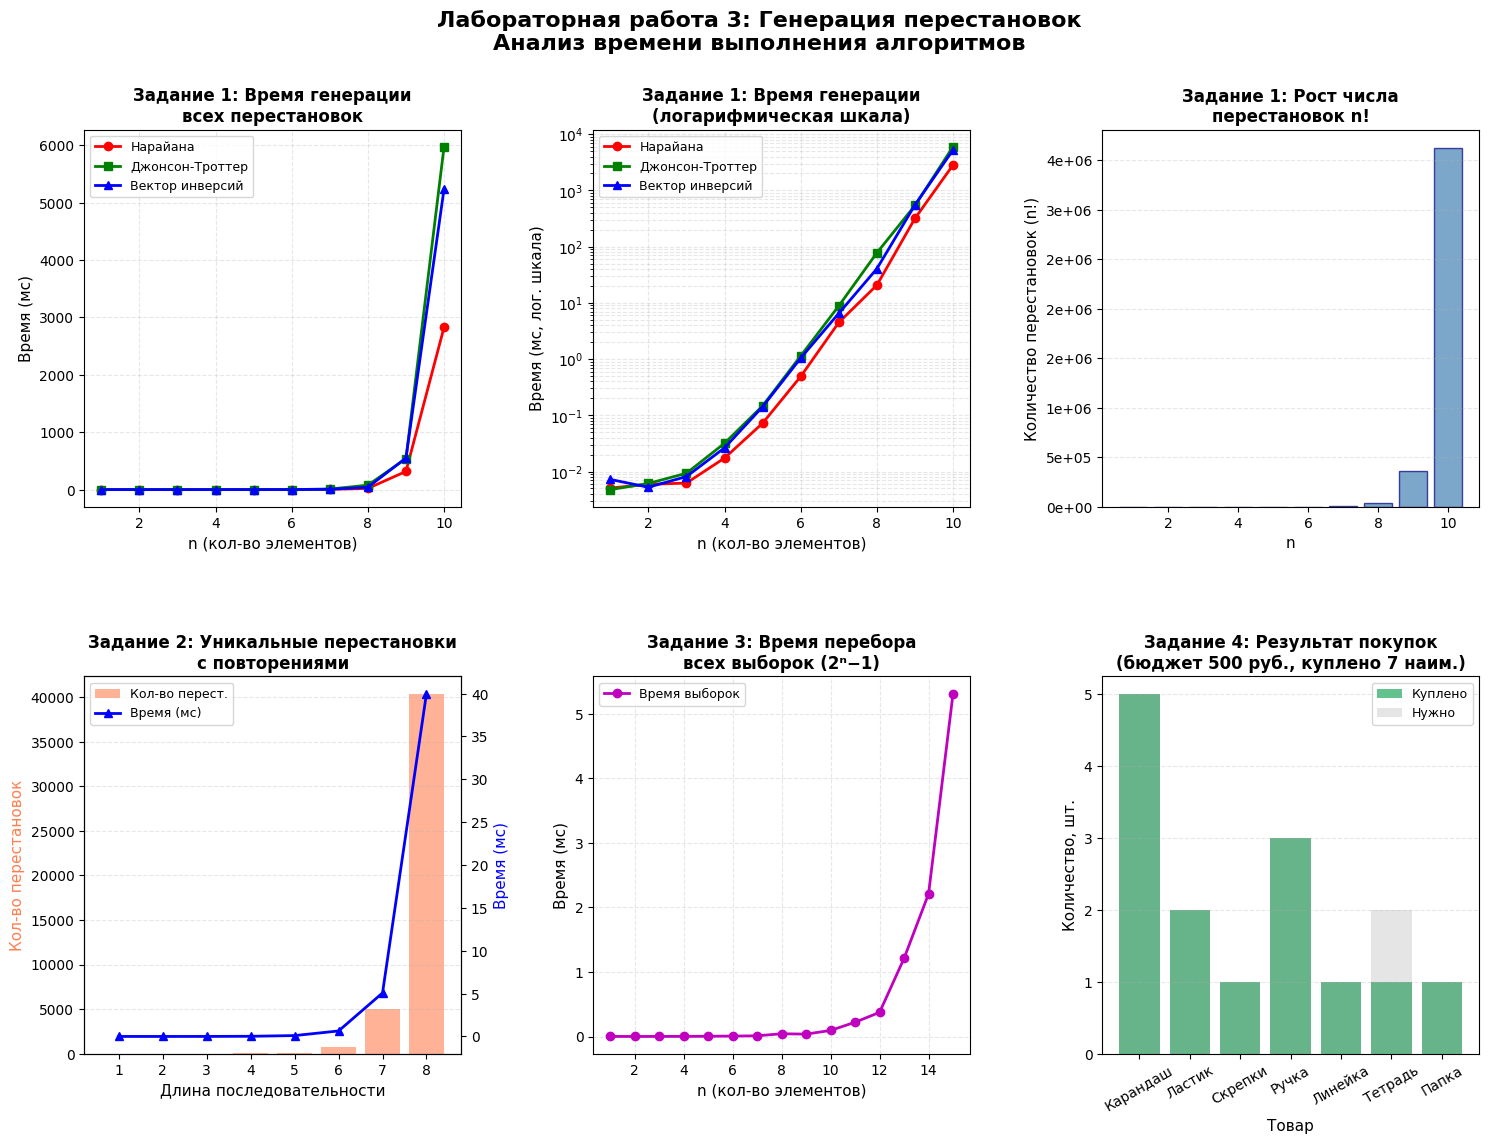


ИТОГОВАЯ СВОДКА

[Задание 1] Среднее время генерации перестановок (n=1..10):
  Нарайана:          317.0373 мс
  Джонсон-Троттер:   659.9650 мс
  Вектор инверсий:   583.5108 мс

[Задание 2] Уникальные перестановки генерируются backtracking-методом
  Время при n=8: 40.0041 мс  (40320 перестановок)

[Задание 3] Перебор всех выборок из 3 элементов:
  Всего вариантов: 7  (= 2^3-1)

[Задание 4] Оптимальная покупка за 500 руб.:
  Куплено 7 наименований, потрачено 480.00 руб.


In [ ]:
print("=" * 75)
print("ЗАДАНИЕ 1: Сравнение алгоритмов генерации перестановок (n = 1..10)")
print("=" * 75)

test_ns = list(range(1, 11))
t_narayana = []
t_johnson = []
t_inversion = []

header = (f"{'n':^5} | {'n!':^10} | "
          f"{'Нарайана (мс)':^16} | {'Джонсон-Троттер (мс)':^22} | "
          f"{'Вектор инверсий (мс)':^22}")
print(header)
print("-" * len(header))

for n in test_ns:
    _, t1 = measure_time(narayana_permutations, n)
    _, t2 = measure_time(johnson_trotter_permutations, n)
    _, t3 = measure_time(inversion_vector_permutations, n)
    t_narayana.append(t1)
    t_johnson.append(t2)
    t_inversion.append(t3)
    print(f"{n:^5} | {factorial(n):^10} | {t1:^16.4f} | {t2:^22.4f} | {t3:^22.4f}")

print()
print(f"Средн. время (мс): Нарайана={np.mean(t_narayana):.4f}  "
      f"Джонсон-Троттер={np.mean(t_johnson):.4f}  "
      f"Вектор инверсий={np.mean(t_inversion):.4f}")

print()
print("=" * 75)
print("ЗАДАНИЕ 2: Уникальные перестановки (с повторяющимися элементами)")
print("=" * 75)

task2_cases = [
    [1, 2, 1],
    [1, 2, 3],
    [1, 1, 1],
    [1, 2, 2, 3],
]

for seq in task2_cases:
    perms, t = measure_time(unique_permutations, seq)
    print(f"\nПоследовательность: {''.join(map(str, seq))}  "
          f"-> {len(perms)} перестановок  (время: {t:.4f} мс)")
    for p in perms:
        print(f"   {''.join(map(str, p))}")

print()
print("Время для последовательностей разной длины:")
print(f"{'Длина':^8} | {'Кол-во перест.':^16} | {'Время (мс)':^14}")
print("-" * 45)
for length in range(1, 9):
    seq = list(range(1, length + 1))
    perms, t = measure_time(unique_permutations, seq)
    print(f"{length:^8} | {len(perms):^16} | {t:^14.4f}")

print()
print("=" * 75)
print("ЗАДАНИЕ 3: Все возможные выборки из n элементов")
print("=" * 75)

items = ["стол", "стул", "шкаф"]
subsets, t = measure_time(all_subsets, items)
print(f"\nЭлементы: {items}")
print(f"Всего вариантов выборки: {len(subsets)}  (время: {t:.4f} мс)")
for s in subsets:
    print(f"   {s}")

print()
print("Время для разного числа элементов:")
print(f"{'n':^6} | {'Кол-во выборок':^16} | {'Время (мс)':^14}")
print("-" * 42)
t_subsets = []
subset_ns = list(range(1, 16))
for n in subset_ns:
    elems = list(range(1, n + 1))
    subs, t = measure_time(all_subsets, elems)
    t_subsets.append(t)
    print(f"{n:^6} | {len(subs):^16} | {t:^14.4f}")


print()
print("=" * 75)
print("ЗАДАНИЕ 4: Покупка канцелярских принадлежностей студента Петрова П.П.")
print("=" * 75)

budget = 500.0
shopping_list = [
    ("Ручка",     3),
    ("Тетрадь",   2),
    ("Карандаш",  5),
    ("Линейка",   1),
    ("Ластик",    2),
    ("Скрепки",   1),
    ("Папка",     1),
]
price_list = {
    "Ручка":     30.0,
    "Тетрадь":   80.0,
    "Карандаш":  15.0,
    "Линейка":   50.0,
    "Ластик":    20.0,
    "Скрепки":   25.0,
    "Папка":    120.0,
    "Степлер":  200.0,
}

print(f"\nБюджет студента: {budget:.2f} руб.")
print("\nСписок необходимых покупок:")
print(f"  {'Наименование':<15} | {'Нужно, шт.':^12} | {'Цена/шт., руб.':^16}")
print("  " + "-" * 48)
for name, qty in shopping_list:
    price = price_list.get(name, "—")
    price_str = f"{price:.2f}" if isinstance(price, float) else price
    print(f"  {name:<15} | {qty:^12} | {price_str:^16}")

(selected, spent), t_task4 = measure_time(stationery_purchase,
                                           budget, shopping_list, price_list)

print(f"\nРезультат (время поиска: {t_task4:.4f} мс):")
print(f"  {'Наименование':<15} | {'Куплено, шт.':^14} | {'Сумма, руб.':^14}")
print("  " + "-" * 48)
for name, qty in selected.items():
    total_price = qty * price_list[name]
    print(f"  {name:<15} | {qty:^14} | {total_price:^14.2f}")
print("  " + "-" * 48)
print(f"  Куплено наименований: {len(selected)} из {len(shopping_list)}")
print(f"  Потрачено: {spent:.2f} руб.  |  Остаток: {budget - spent:.2f} руб.")

print()
print("Построение графиков...")

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Лабораторная работа 3: Генерация перестановок\n"
             "Анализ времени выполнения алгоритмов",
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

#График 1: Время алгоритмов
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(test_ns, t_narayana,   'ro-', lw=2, ms=6, label='Нарайана')
ax1.plot(test_ns, t_johnson,    'gs-', lw=2, ms=6, label='Джонсон-Троттер')
ax1.plot(test_ns, t_inversion,  'b^-', lw=2, ms=6, label='Вектор инверсий')
ax1.set_xlabel('n (кол-во элементов)', fontsize=11)
ax1.set_ylabel('Время (мс)', fontsize=11)
ax1.set_title('Задание 1: Время генерации\nвсех перестановок', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, ls='--')
ax1.legend(fontsize=9)

#График 2: Логарифмическая шкала
ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogy(test_ns, [max(t, 1e-6) for t in t_narayana],  'ro-', lw=2, ms=6, label='Нарайана')
ax2.semilogy(test_ns, [max(t, 1e-6) for t in t_johnson],   'gs-', lw=2, ms=6, label='Джонсон-Троттер')
ax2.semilogy(test_ns, [max(t, 1e-6) for t in t_inversion], 'b^-', lw=2, ms=6, label='Вектор инверсий')
ax2.set_xlabel('n (кол-во элементов)', fontsize=11)
ax2.set_ylabel('Время (мс, лог. шкала)', fontsize=11)
ax2.set_title('Задание 1: Время генерации\n(логарифмическая шкала)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, ls='--', which='both')
ax2.legend(fontsize=9)

#График 3: Теоретическая сложность n!
ax3 = fig.add_subplot(gs[0, 2])
factorials = [factorial(n) for n in test_ns]
ax3.bar(test_ns, factorials, color='steelblue', alpha=0.7, edgecolor='navy')
ax3.set_xlabel('n', fontsize=11)
ax3.set_ylabel('Количество перестановок (n!)', fontsize=11)
ax3.set_title('Задание 1: Рост числа\nперестановок n!', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, ls='--', axis='y')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0e}'))

#График 4: Уникальные перестановки (задание 2)
ax4 = fig.add_subplot(gs[1, 0])
lengths = list(range(1, 9))
counts_uniq = []
times_uniq = []
for length in lengths:
    seq = list(range(1, length + 1))
    perms, t = measure_time(unique_permutations, seq)
    counts_uniq.append(len(perms))
    times_uniq.append(t)
ax4_twin = ax4.twinx()
ax4.bar(lengths, counts_uniq, color='coral', alpha=0.6, label='Кол-во перест.')
ax4_twin.plot(lengths, times_uniq, 'b^-', lw=2, ms=6, label='Время (мс)')
ax4.set_xlabel('Длина последовательности', fontsize=11)
ax4.set_ylabel('Кол-во перестановок', fontsize=11, color='coral')
ax4_twin.set_ylabel('Время (мс)', fontsize=11, color='blue')
ax4.set_title('Задание 2: Уникальные перестановки\nс повторениями', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, ls='--', axis='y')
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

#График 5: Выборки (задание 3)
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(subset_ns, t_subsets, 'mo-', lw=2, ms=6, label='Время выборок')
ax5.set_xlabel('n (кол-во элементов)', fontsize=11)
ax5.set_ylabel('Время (мс)', fontsize=11)
ax5.set_title('Задание 3: Время перебора\nвсех выборок (2ⁿ−1)', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, ls='--')
ax5.legend(fontsize=9)

#График 6: Покупки (задание 4)
ax6 = fig.add_subplot(gs[1, 2])
names = list(selected.keys())
qtys = [selected[n] for n in names]
needed = {name: qty for name, qty in shopping_list}
ax6.bar(names, qtys, color='mediumseagreen', alpha=0.8, label='Куплено')
ax6.bar(names, [needed[n] for n in names], alpha=0.2,
        color='gray', label='Нужно')
ax6.axhline(0, color='black', linewidth=0.5)
ax6.set_xlabel('Товар', fontsize=11)
ax6.set_ylabel('Количество, шт.', fontsize=11)
ax6.set_title(f'Задание 4: Результат покупок\n(бюджет {budget:.0f} руб., '
              f'куплено {len(selected)} наим.)', fontsize=12, fontweight='bold')
ax6.tick_params(axis='x', rotation=30)
ax6.grid(True, alpha=0.3, ls='--', axis='y')
ax6.legend(fontsize=9)

plt.tight_layout()
plt.show()

print()
print("=" * 75)
print("ИТОГОВАЯ СВОДКА")
print("=" * 75)
print(f"\n[Задание 1] Среднее время генерации перестановок (n=1..10):")
print(f"  Нарайана:          {np.mean(t_narayana):.4f} мс")
print(f"  Джонсон-Троттер:   {np.mean(t_johnson):.4f} мс")
print(f"  Вектор инверсий:   {np.mean(t_inversion):.4f} мс")
print(f"\n[Задание 2] Уникальные перестановки генерируются backtracking-методом")
print(f"  Время при n=8: {times_uniq[-1]:.4f} мс  ({factorial(8)} перестановок)")
print(f"\n[Задание 3] Перебор всех выборок из {len(items)} элементов:")
print(f"  Всего вариантов: {len(subsets)}  (= 2^{len(items)}-1)")
print(f"\n[Задание 4] Оптимальная покупка за {budget:.0f} руб.:")
print(f"  Куплено {len(selected)} наименований, потрачено {spent:.2f} руб.")
